# SpaPath breast cancer workflow

This notebook follows one linear workflow: load healthy and disease data, attach image embeddings, preprocess and build graphs, learn initial embeddings, cluster, integrate, detect pathological regions, and identify signature genes.

## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings

import scanpy as sc
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import spapath_model
import spapath_utils

warnings.filterwarnings("ignore")

In [2]:
DATASET_ID = "BC"
HEALTHY_SECTION = "V07"
DISEASE_SECTION = "H1"
DEVICE = "cuda"
SEED = 123

DATA_ROOT = Path("/share/data/wuyd")
PROCESSED_DIR = DATA_ROOT / "SpaPAD" / "processed" / DATASET_ID
OUTPUT_DIR = DATA_ROOT / "SpaPAD" / "outs" / DATASET_ID
FIGURE_DIR = OUTPUT_DIR / "fig"

for output_path in (OUTPUT_DIR, FIGURE_DIR):
    spapath_utils.create_dir(output_path)

adata_type_map = {
    HEALTHY_SECTION: "ST_with_HE",
    DISEASE_SECTION: "ST_with_HE",
}
sections = list(adata_type_map)

CELLTYPE_PALETTE = {
    "adipose tissue": "#227DB5",
    "breast glands": "#9FCCE3",
    "connective tissue": "#3A9339",
    "immune infiltrate": "#9ED594",
    "others": "#A47748",
    "cancer in situ": "#FFD966",
    "invasive cancer": "#B34F8D",
}

/share/data/wuyd/SpaPAD/outs/BC has been created or already exists.
/share/data/wuyd/SpaPAD/outs/BC/fig has been created or already exists.


## 1. Read healthy and disease data

In [3]:
healthy_adata = sc.read_h5ad(PROCESSED_DIR / f"{HEALTHY_SECTION}.h5ad")
disease_adata = sc.read_h5ad(PROCESSED_DIR / f"{DISEASE_SECTION}.h5ad")

datasets = {
    HEALTHY_SECTION: healthy_adata,
    DISEASE_SECTION: disease_adata,
}

## 2. Attach image embeddings

In [4]:
for section, adata in datasets.items():
    embedding_path = (
        PROCESSED_DIR / "spatial" / f"{section}_image_embeddings.csv"
    )
    spapath_utils.attach_image_embedding(adata, embedding_path)

## 3. Preprocess data and build graphs

In [5]:
batch_list = [healthy_adata, disease_adata]
adata_full, disease_adata_all_genes = spapath_utils.preprocess(
    adata_list=batch_list,
    adata_type_map=adata_type_map,
    full_num_hvgs=3000,
    min_genes_qc=10,
    min_cells_qc=10,
)

adata_full = spapath_utils.build_graph_GAT_plus(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    K=8,
    img_threshold=0.0,
)

shape of adata 0 before quality control: (2086, 36393)
shape of adata 0 after quality control: (2086, 13642)
shape of adata 1 before quality control: (530, 15029)
shape of adata 1 after quality control: (530, 8721)
Find 7978 shared genes among datasets.
Normalize data...
Find 3000 shared highly variable genes among datasets.
Start building graphs...
Building sparse graph for batch V07 (ST_with_HE) using NearestNeighbors...
  Image similarity quantiles (neighbors only): [-0.78292766  0.08484013  0.33256572  0.63993939  1.        ]
  Average neighbors for Slice V07: 6.41
Building sparse graph for batch H1 (ST_with_HE) using NearestNeighbors...
  Image similarity quantiles (neighbors only): [-0.578242    0.03440647  0.36520232  0.64929606  1.        ]
  Average neighbors for Slice H1: 5.97


## 4. Learn initial embeddings

In [6]:
model = spapath_model.Model(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    lr_pre=1e-4,
    lr=1e-4,
    n_pre_training_steps=500,
    n_training_steps=300,
    device=DEVICE,
    seed=SEED,
)

adata_full = model.initial_embedding()

Pretrain slice 1: 100%|██████████| 500/500 [00:00<00:00, 524.18it/s]


## 5. Cluster observations

In [7]:
adata_full = model.clustering(
    init_res=1.5,
    intopk=40,
)

There are 16 initial clusters for Slice - 0
There are 13 initial clusters for Slice - 1
There are 7 clusters for Slice - 0 after merging.
There are 9 clusters for Slice - 1 after merging.
[Cluster size] Slice 0 after merge: 0:361(0.173), 1:615(0.295), 2:439(0.210), 3:353(0.169), 4:142(0.068), 5:118(0.057), 6:58(0.028)
[Cluster size] Slice 1 after merge: 0:250(0.472), 1:56(0.106), 2:50(0.094), 3:38(0.072), 4:33(0.062), 5:32(0.060), 6:31(0.058), 7:29(0.055), 8:11(0.021)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


## 6. Integrate healthy and disease data

In [8]:
adata_full = model.integrate(topk=40)

  0%|          | 1/300 [00:00<02:12,  2.26it/s]

Integration step 0: matched target clusters [2]; far-cluster pool [4].
Training step 0: reconstruction=32.8012, inter-cluster=2.3136, intra-cluster=6.5081, geometry=454.6693.


 35%|███▌      | 106/300 [00:04<00:08, 23.66it/s]

Integration step 100: matched target clusters [0, 2, 7]; far-cluster pool [3, 4, 5, 6, 8].
Training step 100: reconstruction=33.0688, inter-cluster=0.2182, intra-cluster=6.7262, geometry=80.0375.


 68%|██████▊   | 205/300 [00:08<00:04, 21.91it/s]

Integration step 200: matched target clusters [0, 2, 7]; far-cluster pool [1, 3, 4, 5, 6, 8].
Training step 200: reconstruction=32.7497, inter-cluster=0.0209, intra-cluster=6.8331, geometry=57.3937.


100%|██████████| 300/300 [00:12<00:00, 24.99it/s]


Integration completed; cell embeddings, gene embeddings, and cell-gene distances were stored.


## 7. Detect pathological regions

In [9]:
adata_full = spapath_utils.detection(
    adata=adata_full,
    embed="cell_embed",
    section_ids=sections,
    label_core="Pathological regions",
    label_other="Healthy-like regions",
    core_types=["cancer in situ", "invasive cancer"],
    celltype_key="CellType",
    batch_key="batch",
    seed=SEED,
    neighbors=30,
    threshold=0.05,
    strategy="individual",
)

display(adata_full.uns["result"])

Detection completed at the observation level.


,DTS,F1,Balanced Accuracy,Accuracy,Precision,Recall,specificity
0,0.910898,0.891041,0.930754,0.915094,0.814159,0.983957,0.877551


Detection UMAP was saved to /share/data/wuyd/SpaPAD/outs/BC/fig/H1_detection_umap.png.


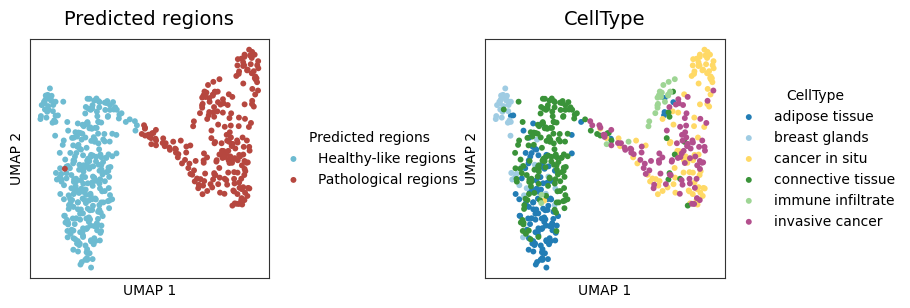

In [10]:
detection_figure = spapath_utils.plot_detection_umap(
    adata=adata_full,
    embed="cell_embed",
    section_id=DISEASE_SECTION,
    batch_key="batch",
    label_key="pred_label",
    celltype_key="CellType",
    celltype_palette=CELLTYPE_PALETTE,
    seed=SEED,
    point_size=18,
    save=FIGURE_DIR / f"{DISEASE_SECTION}_detection_umap.png",
)

## 8. Identify and display signature genes

In [11]:
disease_data = spapath_utils.build_disease_data(
    adata_full=adata_full,
    disease_adata_all_genes=disease_adata_all_genes,
    disease_section=DISEASE_SECTION,
)

pathological_signature_genes = spapath_utils.calculate_signature_genes(
    disease_data,
    target_label="Pathological regions",
    topk=100,
    n_print=10,
)

Top 10 signature genes for Pathological regions:
 rank    gene
    1  PPP6R2
    2  SEC16A
    3   SSRP1
    4  MMACHC
    5    ULK1
    6    GUSB
    7 PTTG1IP
    8    TBCB
    9   FOXM1
   10   CDC20


Gene-expression plot was saved to /share/data/wuyd/SpaPAD/outs/BC/fig/H1_signature_genes.png.


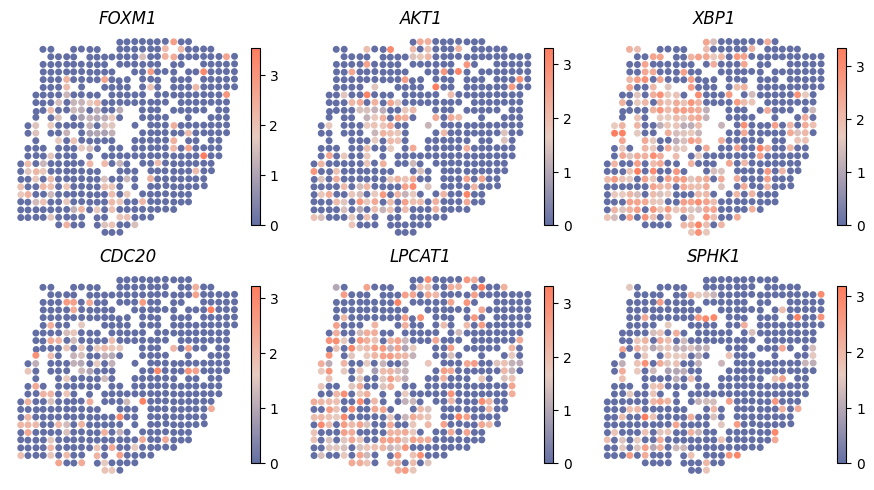

In [12]:
spapath_utils.plot_gene_expression(
    disease_data,
    genes=["FOXM1", "AKT1", "XBP1", "CDC20", "LPCAT1", "SPHK1"],
    save=FIGURE_DIR / f"{DISEASE_SECTION}_signature_genes.png",
)

## 9. GO and Hallmark enrichment

In [15]:
enrichment_results = spapath_utils.run_signature_enrichment(
    pathological_signature_genes[:100],
    group_name="Pathological regions",
    min_count=5,
)

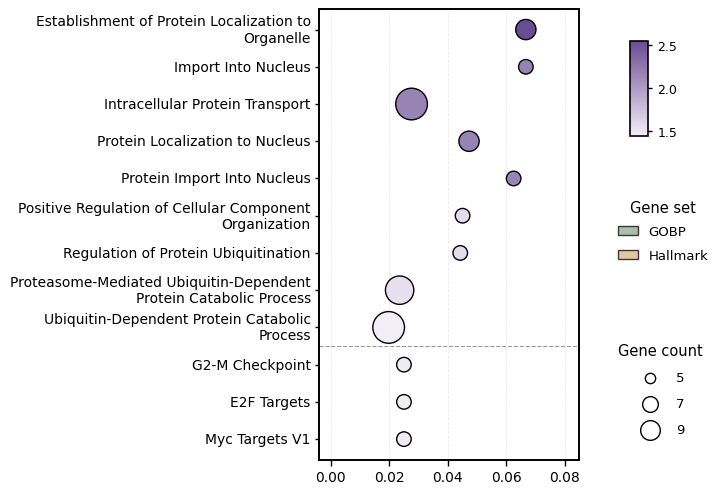

In [16]:
spapath_utils.plot_enrichment_bubble(
    enrichment_results,
    save=FIGURE_DIR / f"{DISEASE_SECTION}_gobp_hallmark_bubble.png",
)